In [ ]:
import numpy as np
import pandas as pd
import warnings
import requests
from bs4 import BeautifulSoup

warnings.filterwarnings('ignore')

In [ ]:
url = 'https://renatomaaliw3.github.io/prelims.html'
headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:136.0) Gecko/20100101 Firefox/136.0'}
response = requests.get(url = url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')

##Scraping data

In [ ]:
table = soup.find('table', attrs = {'id':'set_d'})

In [ ]:
tbody = table.find('tbody')

In [ ]:
rows = tbody.find_all('tr')
data = []
for row in rows:
  cols = [elmt.get_text().strip() for elmt in row.find_all('td')]
  data.append(cols)
df = pd.DataFrame(data, columns = ['Date', 'Value'])
df.set_index('Date', inplace = True)
df.index = pd.to_datetime(df.index)
df['Value'] = df['Value'].astype(float)
df

,Value
Date,
1979-01-01,10.993428
1979-01-02,10.807232
1979-01-03,13.425426
1979-01-04,16.140409
1979-01-05,13.467089
...,...
1981-09-22,70.858923
1981-09-23,77.194545
1981-09-24,76.024832


##Checking Appropriate prediction model

In [ ]:
from statsmodels.tsa.seasonal import STL

<Axes: xlabel='Date'>

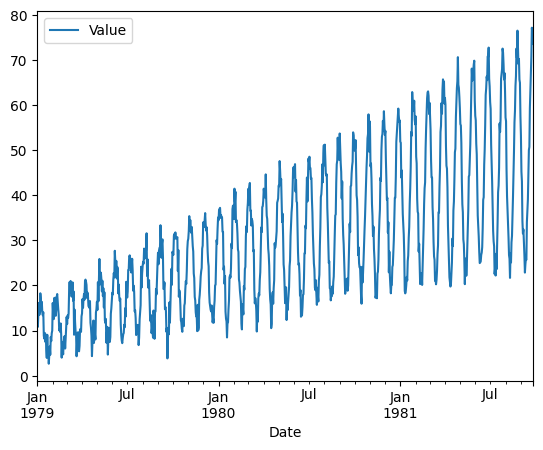

In [ ]:
df.plot()

##Using STL

In [ ]:
decomposed = STL(df['Value'], period = 365).fit()

<Axes: xlabel='Date'>

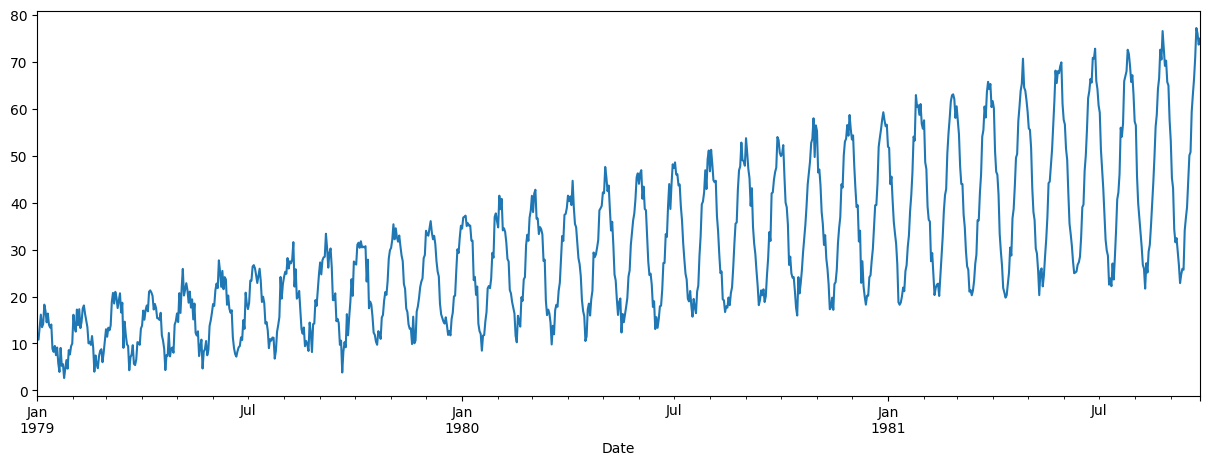

In [ ]:
decomposed.observed.plot(figsize = (15, 5))

<Axes: xlabel='Date'>

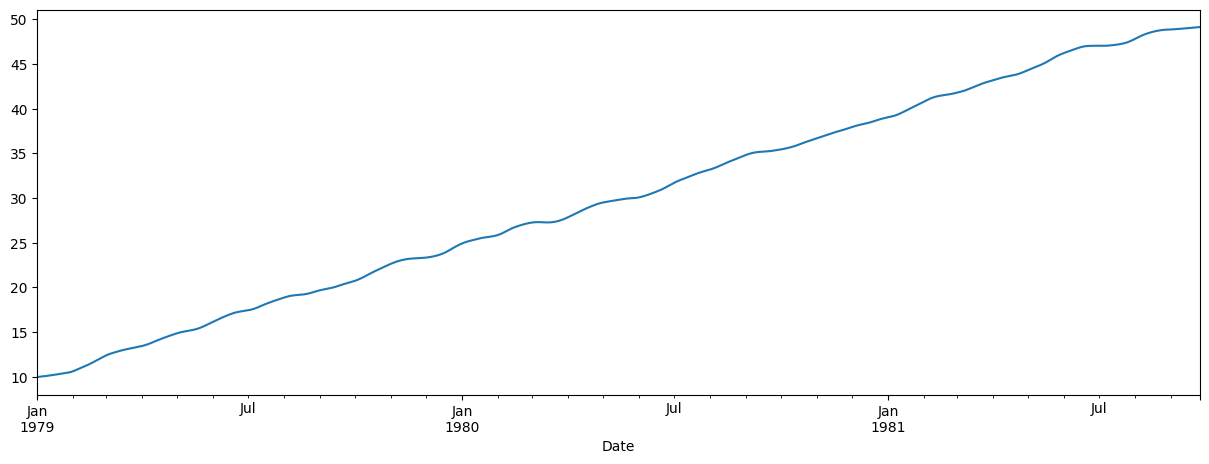

In [ ]:
decomposed.trend.plot(figsize = (15, 5))

The graph has trend. It is linear

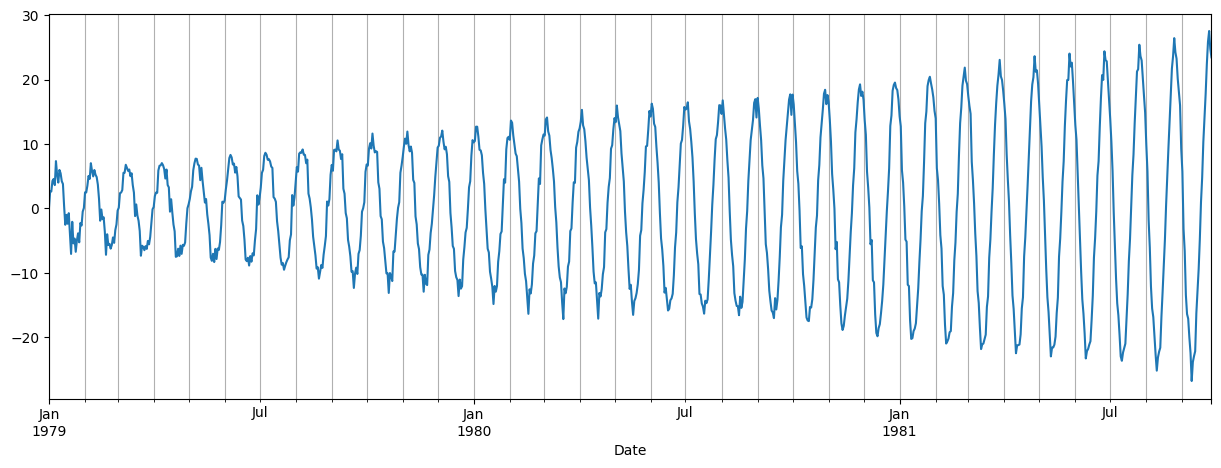

In [ ]:
ax = decomposed.seasonal.plot(figsize = (15, 5))
ax.xaxis.grid(which = 'both')


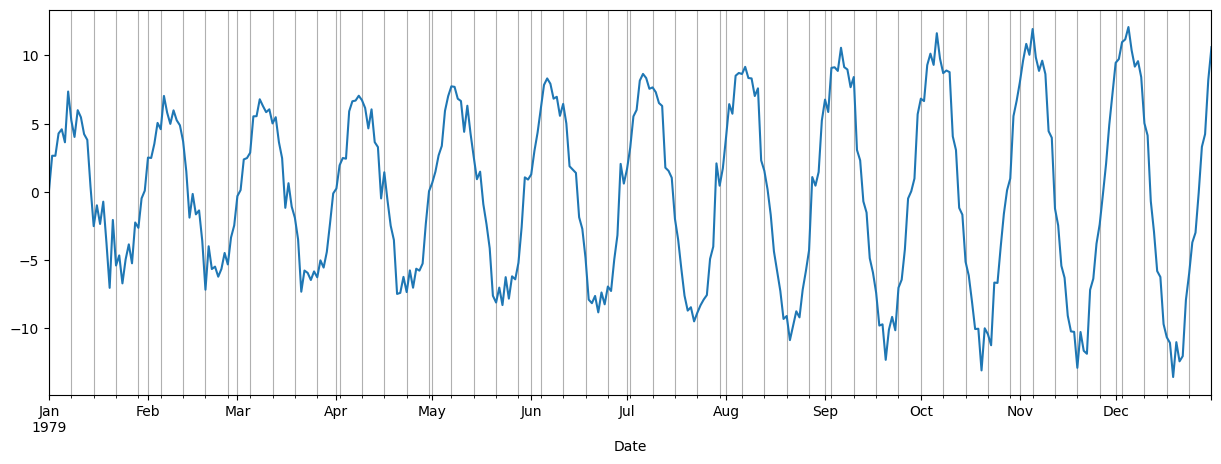

In [ ]:
ax = decomposed.seasonal['1979':'1979'].plot(figsize = (15, 5))
ax.xaxis.grid(which = 'both')


Verdict: There is a seasonality with a period of 1 month (it peaks every month)

##Conclusion: TES is most appropriate

##Forecasting

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
f_horizon = 21
training_data = df.iloc[:-f_horizon]
test_data = df.iloc[-f_horizon:]
test_data

,Value
Date,
1981-09-06,32.438963
1981-09-07,29.489624
1981-09-08,26.696505
1981-09-09,22.860796
1981-09-10,24.719455
1981-09-11,25.901384
1981-09-12,25.714805
1981-09-13,34.101067
1981-09-14,36.720822


In [ ]:
model = ExponentialSmoothing(training_data, trend = 'add', seasonal = 'mul', seasonal_periods = 30).fit()

In [ ]:
forecast = model.forecast(f_horizon)
forecast

,0
1981-09-06,31.273718
1981-09-07,28.297258
1981-09-08,25.255717
1981-09-09,24.126495
1981-09-10,25.821985
1981-09-11,26.707476
1981-09-12,27.570139
1981-09-13,31.083678
1981-09-14,34.595701
1981-09-15,40.765890


In [ ]:
import matplotlib.pyplot as plt

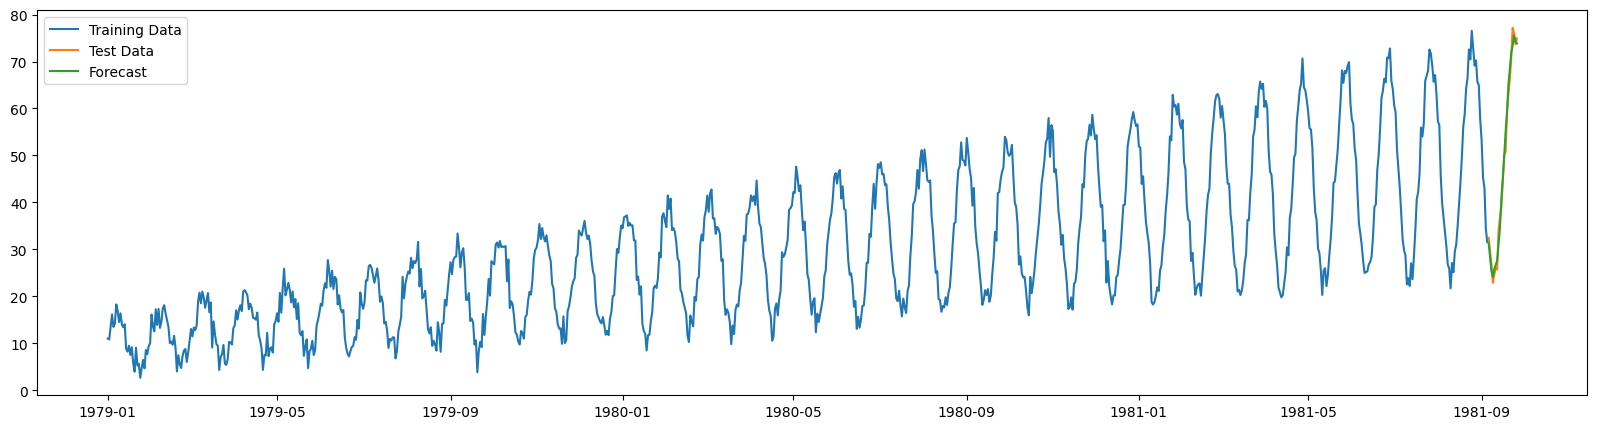

In [ ]:
plt.figure(figsize = (20,5))

plt.plot(training_data.index, training_data['Value'], label = 'Training Data')
plt.plot(test_data.index, test_data['Value'], label = 'Test Data')
plt.plot(forecast.index, forecast, label = 'Forecast')
plt.legend()

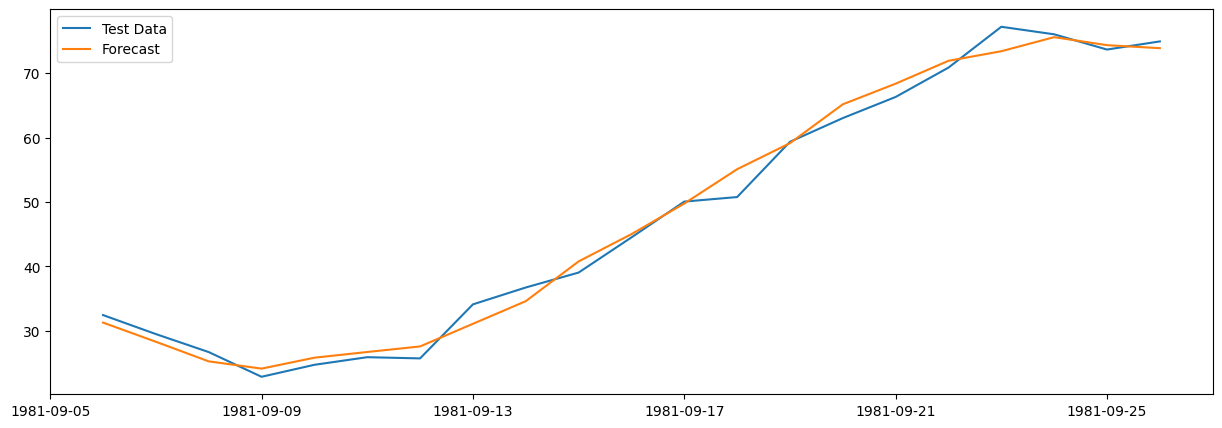

In [ ]:
plt.figure(figsize = (15,5))
plt.plot(test_data.index, test_data['Value'], label = 'Test Data')
plt.plot(forecast.index, forecast, label = 'Forecast')
plt.legend()

In [ ]:
forecast14th = forecast.iloc[13]
forecast14th

np.float64(59.12662672752105)

In [ ]:
test14th = test_data['Value'].iloc[13]
test14th

np.float64(59.3367809)

In [ ]:
error = abs((test14th - forecast14th) / test14th) * 100
error

np.float64(0.35417184635129284)

In [ ]:
model = ExponentialSmoothing(df, trend = 'add', seasonal = 'mul', seasonal_periods = 30).fit()

In [ ]:
forecast = model.forecast(21)

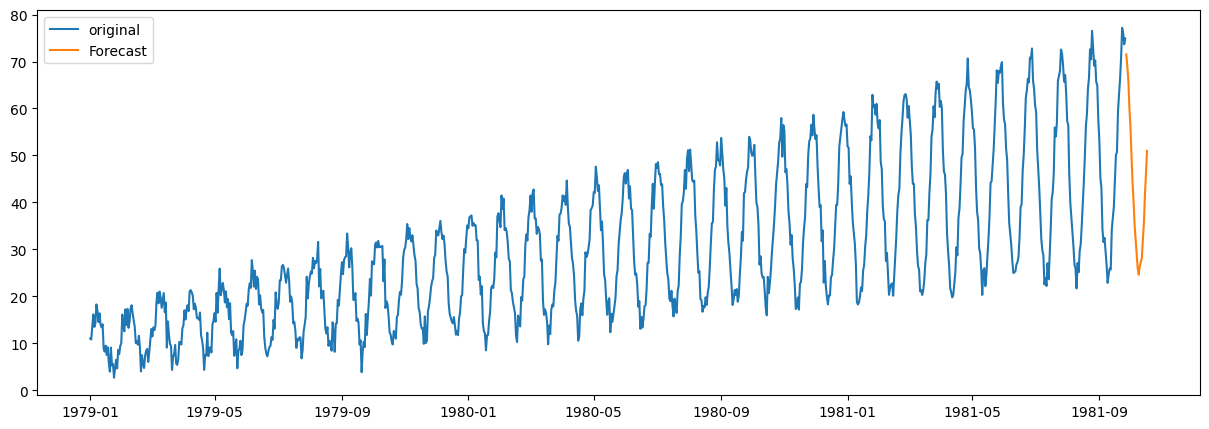

In [ ]:
plt.figure(figsize = (15,5))
plt.plot(df.index, df, label = 'original')
plt.plot(forecast.index, forecast, label = 'Forecast')
plt.legend()

In [ ]:
forecast[-1]

np.float64(50.9807753866871)